# Logical CSB Pauli-noise learning and PEC

This notebook implements the single-logical-qubit workflow used in the manuscript:

1. run CSB for logical `RZ90`, `RX90`, and `RY90` cycles;
2. fit the complex transverse eigenvalues and axis spectral factors;
3. infer the effective logical Pauli model from `RZ90 + RX90`;
4. validate the learned model with held-out `RY90` spectra;
5. construct the quasiprobability inverse and test logical PEC on independent random Clifford circuits;
6. independently repeat the complete workflow 10 times and use the run-to-run standard deviation as the plotted error bar.


In [1]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import logical_csb as sim
importlib.reload(sim)

# -----------------------------------------------------------------------------
# Paper figure style
# -----------------------------------------------------------------------------
PLOT_DPI = 600

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


def style_axis(ax):
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.grid(False)


def add_panel_label(ax, label):
    ax.text(
        -0.12, 1.015, label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="right",
        va="bottom",
        clip_on=False,
    )


def mean_std_summary(df, group_cols, value_cols):
    """Mean/std across independent complete-workflow repeats."""
    value_cols = [c for c in value_cols if c in df.columns]
    if group_cols:
        agg = {}
        for c in value_cols:
            agg[f"{c}_mean"] = (c, "mean")
            agg[f"{c}_std"] = (c, "std")
        agg["n_repeats"] = ("repeat_id", "nunique")
        out = df.groupby(group_cols, as_index=False).agg(**agg)
    else:
        row = {"n_repeats": int(df["repeat_id"].nunique())}
        for c in value_cols:
            vals = df[c].to_numpy(dtype=float)
            row[f"{c}_mean"] = float(np.nanmean(vals))
            row[f"{c}_std"] = float(np.nanstd(vals, ddof=1)) if np.sum(np.isfinite(vals)) > 1 else 0.0
        out = pd.DataFrame([row])
    for c in out.columns:
        if c.endswith("_std"):
            out[c] = out[c].fillna(0.0)
    return out


## Settings


`CSB_SHOTS=1000` is the requested total for each CSB spectral mode. For a complex transverse mode, the implementation splits this total equally between the real and imaginary quadratures; the axis branch uses the full requested shot count.

`N_REPEATS=10` means that the entire pipeline

`CSB sampling -> spectral fitting -> Pauli inference -> held-out validation -> PEC`

is independently rerun ten times. 

In [2]:
# -----------------------------------------------------------------------------
# Randomness and parallel execution
# -----------------------------------------------------------------------------
BASE_SEED = 1234
N_JOBS = -1

# -----------------------------------------------------------------------------
# Flagged Steane FTEC decoder
# -----------------------------------------------------------------------------
MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = "steane_flag_decoder_stabilizer_max4.pkl"

# -----------------------------------------------------------------------------
# Circuit-level stochastic Pauli noise
# -----------------------------------------------------------------------------
NOISE_STRENGTH = 3e-4
TWO_QUBIT_FACTOR = 2.0
FINAL_MEAS_FACTOR = 1.0

noise = sim.make_homogeneous_noise(
    strength=NOISE_STRENGTH,
    two_qubit_factor=TWO_QUBIT_FACTOR,
    final_meas_factor=FINAL_MEAS_FACTOR,
)

# -----------------------------------------------------------------------------
# Circuit-boundary choices
# -----------------------------------------------------------------------------
CIRCUIT_OPTIONS = {
    "prep_gates_noisy": True,
    "prep_qec_after_gate": True,
    "measurement_basis_gates_noisy": True,
    "qec_after_each_logical_gate": True,
    "fallback_on_unverified": True,
}
CIRCUIT_OPTIONS = sim.validate_circuit_options(CIRCUIT_OPTIONS)

# -----------------------------------------------------------------------------
# CSB learning
# L_s = CSB_REP * s, s = 0,...,12
# -----------------------------------------------------------------------------
TARGET_GATES = ("RZ90", "RX90", "RY90")
CSB_STEPS = list(range(13))
CSB_REP = 9
CSB_SHOTS = 1000
CSB_CHUNK_SHOTS = 500

# -----------------------------------------------------------------------------
# Independent logical PEC validation
# -----------------------------------------------------------------------------
RUN_RB = True
RB_DEPTHS = [4, 8, 12, 16, 24]
RB_SEQUENCES_PER_DEPTH = 20
RB_NOISY_SHOTS_PER_SEQUENCE = 10000
RB_PEC_SHOTS_PER_SEQUENCE = 10000
NOISY_CHUNK_SHOTS = 500
PEC_CHUNK_SHOTS = 500

# -----------------------------------------------------------------------------
# Independent complete-workflow repeats
# -----------------------------------------------------------------------------
N_REPEATS = 10
RUN_REPEATED_FULL_WORKFLOW = True

# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------
SAVE_DATA = False
RESULTS_FILE = "logical_csb_learning_pec_results.xlsx"
SAVE_PLOTS = True

settings_df = pd.DataFrame([{
    "base_seed": BASE_SEED,
    "noise_strength_p": NOISE_STRENGTH,
    "p_1q": noise.p_1q,
    "p_2q": noise.p_2q,
    "p_meas": noise.p_meas,
    "p_reset": noise.p_reset,
    "p_idle": noise.p_idle,
    "p_final_meas": noise.p_final_meas,
    "min_ec_rounds": MIN_EC_ROUNDS,
    "max_ec_rounds": MAX_EC_ROUNDS,
    "csb_steps": str(CSB_STEPS),
    "csb_rep": CSB_REP,
    "csb_true_depths": str([CSB_REP * s for s in CSB_STEPS]),
    "csb_shots_requested": CSB_SHOTS,
    "csb_chunk_shots": CSB_CHUNK_SHOTS,
    "rb_depths": str(RB_DEPTHS),
    "rb_sequences_per_depth": RB_SEQUENCES_PER_DEPTH,
    "rb_noisy_shots_per_sequence": RB_NOISY_SHOTS_PER_SEQUENCE,
    "rb_pec_shots_per_sequence": RB_PEC_SHOTS_PER_SEQUENCE,
    "n_repeats": N_REPEATS,
    **CIRCUIT_OPTIONS,
}])

display(settings_df)
display(sim.make_csb_depth_table(CSB_STEPS, CSB_REP))


,base_seed,noise_strength_p,p_1q,p_2q,p_meas,p_reset,p_idle,p_final_meas,min_ec_rounds,max_ec_rounds,...,rb_depths,rb_sequences_per_depth,rb_noisy_shots_per_sequence,rb_pec_shots_per_sequence,n_repeats,prep_gates_noisy,prep_qec_after_gate,measurement_basis_gates_noisy,qec_after_each_logical_gate,fallback_on_unverified
0,1234,0.0003,0.0003,0.0006,0.0003,0.0003,0.0003,0.0003,2,4,...,"[4, 8, 12, 16, 24]",20,10000,10000,10,True,True,True,True,True


,step,rep,true_depth_L
0,0,9,0
1,1,9,9
2,2,9,18
3,3,9,27
4,4,9,36
5,5,9,45
6,6,9,54
7,7,9,63
8,8,9,72
9,9,9,81


## Single CSB learning run

This cell runs one complete CSB data set and performs the model inference once. Local fit uncertainties are retained by `logical_csb.py`, but the paper error bars are taken from the independent complete-workflow repeats below.


In [3]:
decoder = sim.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=True,
)

if sim.using_numba():
    sim.warmup_numba(
        decoder=decoder,
        noise=noise,
        options=CIRCUIT_OPTIONS,
        seed=BASE_SEED,
    )

csb_df = sim.run_csb_spectrum(
    decoder=decoder,
    noise=noise,
    options=CIRCUIT_OPTIONS,
    steps=CSB_STEPS,
    rep=CSB_REP,
    shots=CSB_SHOTS,
    seed=BASE_SEED,
    n_jobs=N_JOBS,
    chunk_shots=CSB_CHUNK_SHOTS,
    target_gates=TARGET_GATES,
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=True,
)

spectra_df, pauli_df, eta = sim.infer_pauli_from_csb(csb_df)
ry_validation_df = sim.ry_spectrum_validation_table(pauli_df)
inverse_df = sim.summarize_inverse_channel(pauli_df)

display(spectra_df)
display(pauli_df[[c for c in [
    "p_I", "p_X", "p_Y", "p_Z", "f_X", "f_Y", "f_Z",
    "least_squares_residual_norm", "least_squares_rank"
] if c in pauli_df.columns]])
display(ry_validation_df)
display(inverse_df)


Loaded verified flagged Steane EC decoder.
  decoder bins     = 445
Logical CSB
  target gates = ['RZ90', 'RX90', 'RY90']
  steps        = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  rep          = 9
  true depths  = [0, 9, 18, 27, 36, 45, 54, 63, 72, 81, 90, 99, 108]
  shots        = 1000
  chunk shots  = 500
  n_jobs       = -1


,target_gate,axis,g_offdiag_note,theta_offdiag,delta_theta,lambda_offdiag_real,lambda_offdiag_imag,complex_fit_success,complex_fit_cost,g_axis,g_axis_local_stderr,axis_amplitude,axis_fit_success,axis_fit_cost,process_fidelity,process_infidelity,average_gate_fidelity,average_gate_infidelity,offdiag_equation,axis_equation
0,RZ90,Z,0.995974,1.570528,-0.000268,0.000267,0.995974,True,15.385380,0.996503,0.000154,0.999489,True,4.135597,0.997113,0.002887,0.998075,0.001925,w_I - w_Z,f_Z
1,RX90,X,0.995480,1.571737,0.000941,-0.000936,0.995479,True,9.450428,0.996596,0.000129,0.996384,True,6.050950,0.996889,0.003111,0.997926,0.002074,w_I - w_X,f_X
2,RY90,Y,0.996351,1.571049,0.000252,-0.000251,0.996351,True,17.006777,0.994726,0.000100,0.995511,True,2.170852,0.996857,0.003143,0.997905,0.002095,w_I - w_Y,f_Y


,p_I,p_X,p_Y,p_Z,f_X,f_Y,f_Z,least_squares_residual_norm,least_squares_rank
0,0.997001,0.001342,0.000451,0.001206,0.996686,0.994905,0.996413,0.000283,4


,RY_spectrum,measured,measured_stderr,predicted_from_RZ_RX,predicted_stderr,abs_difference,abs_difference_stderr
0,g_offdiag = w_I - w_Y,0.996351,NaN,0.996549,NaN,0.000199,NaN
1,g_axis = f_Y,0.994726,NaN,0.994905,NaN,0.000178,NaN


,q_I,q_X,q_Y,q_Z,gamma_per_cycle,sampling_overhead_per_cycle
0,1.003012,-0.001349,-0.000451,-0.001212,1.006023,1.012083


## Single independent-circuit PEC validation

For each random Clifford circuit, the ideal inverse word is appended so that the ideal survival probability is one. The CSB-learned Pauli inverse is sampled after each noisy logical cycle. The single-run table below is diagnostic only; paper error bars come from the ten complete-workflow repeats.


In [4]:
if RUN_RB:
    rb_df = sim.run_rb_pec_experiment(
        decoder=decoder,
        noise=noise,
        options=CIRCUIT_OPTIONS,
        pauli_df=pauli_df,
        rb_depths=RB_DEPTHS,
        nseq=RB_SEQUENCES_PER_DEPTH,
        noisy_shots=RB_NOISY_SHOTS_PER_SEQUENCE,
        pec_shots=RB_PEC_SHOTS_PER_SEQUENCE,
        seed=BASE_SEED + 404,
        n_jobs=N_JOBS,
        noisy_chunk_shots=NOISY_CHUNK_SHOTS,
        pec_chunk_shots=PEC_CHUNK_SHOTS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=True,
    )
    display(rb_df)
else:
    rb_df = pd.DataFrame()
    print("RUN_RB=False; independent-circuit PEC validation skipped.")


Logical RB/PEC
  depths              = [4, 8, 12, 16, 24]
  sequences/depth     = 20
  noisy shots/sequence= 10000
  PEC shots/sequence  = 10000
  n_jobs              = -1


,rb_depth,num_sequences,mean_total_primitive_gates,noisy_expectation,pec_expectation,postprocessed_spectral_check,noisy_std_across_sequences,pec_std_across_sequences
0,4,20,6.5,0.97604,1.001230,1.001042,0.003025,0.003079
1,8,20,10.2,0.96071,0.999069,1.001171,0.003625,0.004485
2,12,20,14.4,0.94378,1.000387,0.999845,0.006543,0.004365
3,16,20,18.9,0.92849,1.000326,1.000498,0.005610,0.004020
4,24,20,26.8,0.89943,0.999582,1.001438,0.007199,0.007250


## Ten independent complete-workflow repetitions

Each repeat regenerates the CSB shot data, refits the spectra, reinfers the Pauli model, reruns the held-out `RY90` validation, and reruns the random-circuit PEC experiment. The reported standard deviation is the standard deviation of these repeat-level estimates, not a standard error of the mean.


In [5]:
if RUN_REPEATED_FULL_WORKFLOW:
    spectra_repeat_frames = []
    pauli_repeat_frames = []
    ry_repeat_frames = []
    inverse_repeat_frames = []
    rb_repeat_frames = []

    for repeat_id in range(N_REPEATS):
        repeat_seed = BASE_SEED + repeat_id * 1_000_003
        print(f"repeat {repeat_id + 1:2d}/{N_REPEATS} | seed={repeat_seed}")

        csb_repeat = sim.run_csb_spectrum(
            decoder=decoder,
            noise=noise,
            options=CIRCUIT_OPTIONS,
            steps=CSB_STEPS,
            rep=CSB_REP,
            shots=CSB_SHOTS,
            seed=repeat_seed,
            n_jobs=N_JOBS,
            chunk_shots=CSB_CHUNK_SHOTS,
            target_gates=TARGET_GATES,
            cache_file=DECODER_CACHE,
            min_rounds=MIN_EC_ROUNDS,
            max_rounds=MAX_EC_ROUNDS,
            verbose=False,
        )

        spectra_repeat, pauli_repeat, _eta_repeat = sim.infer_pauli_from_csb(csb_repeat)

        spectra_repeat = spectra_repeat.copy()
        spectra_repeat["repeat_id"] = repeat_id
        spectra_repeat_frames.append(spectra_repeat)

        pauli_repeat = pauli_repeat.copy()
        pauli_repeat["repeat_id"] = repeat_id
        pauli_repeat_frames.append(pauli_repeat)

        ry_repeat = sim.ry_spectrum_validation_table(pauli_repeat).copy()
        ry_repeat["repeat_id"] = repeat_id
        ry_repeat_frames.append(ry_repeat)

        inverse_repeat = sim.summarize_inverse_channel(pauli_repeat).copy()
        inverse_repeat["repeat_id"] = repeat_id
        inverse_repeat_frames.append(inverse_repeat)

        if RUN_RB:
            rb_repeat = sim.run_rb_pec_experiment(
                decoder=decoder,
                noise=noise,
                options=CIRCUIT_OPTIONS,
                pauli_df=pauli_repeat,
                rb_depths=RB_DEPTHS,
                nseq=RB_SEQUENCES_PER_DEPTH,
                noisy_shots=RB_NOISY_SHOTS_PER_SEQUENCE,
                pec_shots=RB_PEC_SHOTS_PER_SEQUENCE,
                seed=repeat_seed + 999,
                n_jobs=N_JOBS,
                noisy_chunk_shots=NOISY_CHUNK_SHOTS,
                pec_chunk_shots=PEC_CHUNK_SHOTS,
                cache_file=DECODER_CACHE,
                min_rounds=MIN_EC_ROUNDS,
                max_rounds=MAX_EC_ROUNDS,
                verbose=False,
            )
            rb_repeat = rb_repeat.copy()
            rb_repeat["repeat_id"] = repeat_id
            rb_repeat_frames.append(rb_repeat)

    spectra_repeats = pd.concat(spectra_repeat_frames, ignore_index=True)
    pauli_repeats = pd.concat(pauli_repeat_frames, ignore_index=True)
    ry_repeats = pd.concat(ry_repeat_frames, ignore_index=True)
    inverse_repeats = pd.concat(inverse_repeat_frames, ignore_index=True)
    rb_repeats = pd.concat(rb_repeat_frames, ignore_index=True) if rb_repeat_frames else pd.DataFrame()
else:
    spectra_repeats = pd.DataFrame()
    pauli_repeats = pd.DataFrame()
    ry_repeats = pd.DataFrame()
    inverse_repeats = pd.DataFrame()
    rb_repeats = pd.DataFrame()
    print("RUN_REPEATED_FULL_WORKFLOW=False; repeated workflow skipped.")


repeat  1/10 | seed=1234
repeat  2/10 | seed=1001237
repeat  3/10 | seed=2001240
repeat  4/10 | seed=3001243
repeat  5/10 | seed=4001246
repeat  6/10 | seed=5001249
repeat  7/10 | seed=6001252
repeat  8/10 | seed=7001255
repeat  9/10 | seed=8001258
repeat 10/10 | seed=9001261


In [6]:
if spectra_repeats.empty:
    raise RuntimeError("Run the repeated complete workflow before building summaries.")

spectra_summary = mean_std_summary(
    spectra_repeats,
    group_cols=["target_gate"],
    value_cols=[
        "g_offdiag_note", "delta_theta", "g_axis",
        "process_fidelity", "process_infidelity",
        "average_gate_fidelity", "average_gate_infidelity",
    ],
).sort_values("target_gate").reset_index(drop=True)

pauli_summary = mean_std_summary(
    pauli_repeats,
    group_cols=[],
    value_cols=[
        "p_I", "p_X", "p_Y", "p_Z",
        "f_X", "f_Y", "f_Z",
        "raw_lstsq_p_I", "raw_lstsq_p_X", "raw_lstsq_p_Y", "raw_lstsq_p_Z",
        "least_squares_residual_norm",
    ],
)

ry_summary = (
    ry_repeats
    .groupby("RY_spectrum", as_index=False)
    .agg(
        measured_mean=("measured", "mean"),
        measured_std=("measured", "std"),
        predicted_mean=("predicted_from_RZ_RX", "mean"),
        predicted_std=("predicted_from_RZ_RX", "std"),
        abs_difference_mean=("abs_difference", "mean"),
        abs_difference_std=("abs_difference", "std"),
        n_repeats=("repeat_id", "nunique"),
    )
)

inverse_summary = mean_std_summary(
    inverse_repeats,
    group_cols=[],
    value_cols=[
        "q_I", "q_X", "q_Y", "q_Z",
        "gamma_per_cycle", "sampling_overhead_per_cycle",
    ],
)

if RUN_RB and not rb_repeats.empty:
    rb_summary = mean_std_summary(
        rb_repeats,
        group_cols=["rb_depth"],
        value_cols=[
            "noisy_expectation", "pec_expectation",
            "postprocessed_spectral_check",
            "mean_total_primitive_gates",
        ],
    ).sort_values("rb_depth").reset_index(drop=True)
else:
    rb_summary = pd.DataFrame()

print("Error bars: standard deviation across 10 independent complete workflows.")
display(spectra_summary)
display(pauli_summary)
display(ry_summary)
display(inverse_summary)
if RUN_RB:
    display(rb_summary)

if SAVE_DATA:
    with pd.ExcelWriter(RESULTS_FILE, engine="openpyxl") as writer:
        settings_df.to_excel(writer, sheet_name="settings", index=False)
        spectra_summary.to_excel(writer, sheet_name="spectra_summary", index=False)
        pauli_summary.to_excel(writer, sheet_name="pauli_summary", index=False)
        ry_summary.to_excel(writer, sheet_name="ry_summary", index=False)
        inverse_summary.to_excel(writer, sheet_name="inverse_summary", index=False)
        if not rb_summary.empty:
            rb_summary.to_excel(writer, sheet_name="pec_summary", index=False)
    print(f"saved: {RESULTS_FILE}")


Error bars: standard deviation across 10 independent complete workflows.


,target_gate,g_offdiag_note_mean,g_offdiag_note_std,delta_theta_mean,delta_theta_std,g_axis_mean,g_axis_std,process_fidelity_mean,process_fidelity_std,process_infidelity_mean,process_infidelity_std,average_gate_fidelity_mean,average_gate_fidelity_std,average_gate_infidelity_mean,average_gate_infidelity_std,n_repeats
0,RX90,0.995611,0.000185,0.000116,0.000505,0.996534,0.000144,0.996939,0.000117,0.003061,0.000117,0.997959,0.000078,0.002041,0.000078,10
1,RY90,0.996606,0.000190,0.000422,0.000432,0.994992,0.000169,0.997051,0.000123,0.002949,0.000123,0.998034,0.000082,0.001966,0.000082,10
2,RZ90,0.995749,0.000222,0.000039,0.000395,0.996582,0.000154,0.997020,0.000111,0.002980,0.000111,0.998014,0.000074,0.001986,0.000074,10


,n_repeats,p_I_mean,p_I_std,p_X_mean,p_X_std,p_Y_mean,p_Y_std,p_Z_mean,p_Z_std,f_X_mean,...,raw_lstsq_p_I_mean,raw_lstsq_p_I_std,raw_lstsq_p_X_mean,raw_lstsq_p_X_std,raw_lstsq_p_Y_mean,raw_lstsq_p_Y_std,raw_lstsq_p_Z_mean,raw_lstsq_p_Z_std,least_squares_residual_norm_mean,least_squares_residual_norm_std
0,10,0.99698,0.000073,0.001304,0.000057,0.000421,0.000076,0.001295,0.000116,0.996567,...,0.99698,0.000073,0.001304,0.000057,0.000421,0.000076,0.001295,0.000116,0.0002,0.00013


,RY_spectrum,measured_mean,measured_std,predicted_mean,predicted_std,abs_difference_mean,abs_difference_std,n_repeats
0,g_axis = f_Y,0.994992,0.000169,0.994802,0.000282,0.000345,0.000184,10
1,g_offdiag = w_I - w_Y,0.996606,0.000190,0.996558,0.000049,0.000169,0.000105,10


,n_repeats,q_I_mean,q_I_std,q_X_mean,q_X_std,q_Y_mean,q_Y_std,q_Z_mean,q_Z_std,gamma_per_cycle_mean,gamma_per_cycle_std,sampling_overhead_per_cycle_mean,sampling_overhead_per_cycle_std
0,10,1.003033,0.000074,-0.00131,0.000057,-0.000421,0.000077,-0.001302,0.000117,1.006066,0.000147,1.012169,0.000296


,rb_depth,noisy_expectation_mean,noisy_expectation_std,pec_expectation_mean,pec_expectation_std,postprocessed_spectral_check_mean,postprocessed_spectral_check_std,mean_total_primitive_gates_mean,mean_total_primitive_gates_std,n_repeats
0,4,0.977118,0.000753,1.001214,0.000856,1.001068,0.000577,6.16,0.183787,10
1,8,0.959471,0.001000,1.001145,0.001098,1.000812,0.001216,10.63,0.205751,10
2,12,0.945029,0.001406,1.000570,0.001974,1.001197,0.001241,14.54,0.267499,10
3,16,0.929012,0.001536,1.001102,0.002036,1.000542,0.001712,18.59,0.314289,10
4,24,0.899744,0.001540,1.000793,0.003364,1.000630,0.003220,26.52,0.282056,10


## Paper figure: CSB spectra, learned Pauli probabilities, and held-out validation

All error bars are run-to-run standard deviations across the ten independent complete workflows.


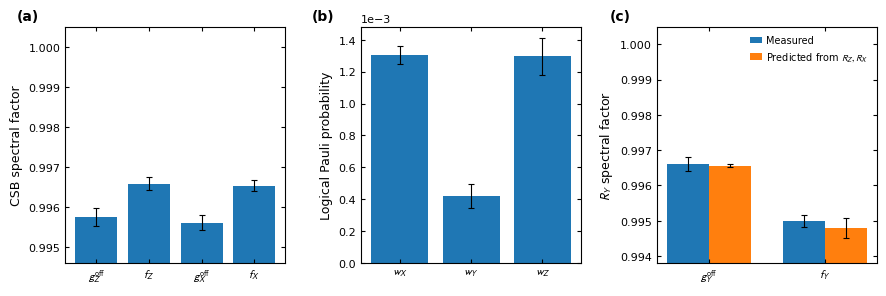

In [8]:
rz_row = spectra_summary.loc[spectra_summary["target_gate"] == "RZ90"].iloc[0]
rx_row = spectra_summary.loc[spectra_summary["target_gate"] == "RX90"].iloc[0]
p_row = pauli_summary.iloc[0]

a_labels = [
    r"$g_Z^{\mathrm{off}}$", r"$f_Z$",
    r"$g_X^{\mathrm{off}}$", r"$f_X$",
]
a_values = np.array([
    rz_row["g_offdiag_note_mean"], rz_row["g_axis_mean"],
    rx_row["g_offdiag_note_mean"], rx_row["g_axis_mean"],
], dtype=float)
a_errors = np.array([
    rz_row["g_offdiag_note_std"], rz_row["g_axis_std"],
    rx_row["g_offdiag_note_std"], rx_row["g_axis_std"],
], dtype=float)

b_labels = [r"$w_X$", r"$w_Y$", r"$w_Z$"]
b_values = np.array([p_row["p_X_mean"], p_row["p_Y_mean"], p_row["p_Z_mean"]], dtype=float)
b_errors = np.array([p_row["p_X_std"], p_row["p_Y_std"], p_row["p_Z_std"]], dtype=float)

ry_off_row = ry_summary.loc[ry_summary["RY_spectrum"] == "g_offdiag = w_I - w_Y"].iloc[0]
ry_axis_row = ry_summary.loc[ry_summary["RY_spectrum"] == "g_axis = f_Y"].iloc[0]

c_labels = [r"$g_Y^{\mathrm{off}}$", r"$f_Y$"]
c_measured = np.array([ry_off_row["measured_mean"], ry_axis_row["measured_mean"]], dtype=float)
c_measured_err = np.array([ry_off_row["measured_std"], ry_axis_row["measured_std"]], dtype=float)
c_predicted = np.array([ry_off_row["predicted_mean"], ry_axis_row["predicted_mean"]], dtype=float)
c_predicted_err = np.array([ry_off_row["predicted_std"], ry_axis_row["predicted_std"]], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(8.8, 2.9))

# (a) Measured RZ/RX spectral factors
ax = axes[0]
xpos = np.arange(len(a_labels))
ax.bar(xpos, a_values, yerr=a_errors, capsize=2, error_kw={"elinewidth": 0.8, "capthick": 0.8})
ax.set_xticks(xpos)
ax.set_xticklabels(a_labels)
ax.set_ylabel("CSB spectral factor")
ax.set_ylim(0.9946, 1.0005)
style_axis(ax)
add_panel_label(ax, "(a)")

# (b) Learned logical Pauli probabilities
ax = axes[1]
xpos = np.arange(len(b_labels))
ax.bar(xpos, b_values, yerr=b_errors, capsize=2, error_kw={"elinewidth": 0.8, "capthick": 0.8})
ax.set_xticks(xpos)
ax.set_xticklabels(b_labels)
ax.set_ylabel("Logical Pauli probability")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.yaxis.get_offset_text().set_size(8)
style_axis(ax)
add_panel_label(ax, "(b)")

# (c) Held-out RY spectral validation
ax = axes[2]
xpos = np.arange(len(c_labels))
width = 0.36
ax.bar(
    xpos - width / 2, c_measured, width=width,
    yerr=c_measured_err, capsize=2,
    error_kw={"elinewidth": 0.8, "capthick": 0.8},
    label="Measured",
)
ax.bar(
    xpos + width / 2, c_predicted, width=width,
    yerr=c_predicted_err, capsize=2,
    error_kw={"elinewidth": 0.8, "capthick": 0.8},
    label=r"Predicted from $R_Z,R_X$",
)
ax.set_xticks(xpos)
ax.set_xticklabels(c_labels)
ax.set_ylabel(r"$R_Y$ spectral factor")
ax.set_ylim(0.9938, 1.0005)
ax.legend(loc="upper right", handlelength=1.2, handletextpad=0.4)
style_axis(ax)
add_panel_label(ax, "(c)")

fig.tight_layout(pad=0.6, w_pad=1.5)


fig.savefig(f"csb_pauli_learning_validation.pdf", bbox_inches="tight")
    

plt.show()


## Paper figure: PEC validation on independent logical circuits

The line connects the mean over complete-workflow repeats at each circuit depth; the vertical error bars are the corresponding run-to-run standard deviations.


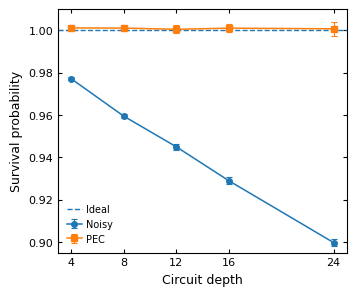

In [9]:
if not RUN_RB or rb_summary.empty:
    raise RuntimeError("PEC summary is unavailable. Run with RUN_RB=True.")

plot_rb = rb_summary.sort_values("rb_depth").reset_index(drop=True)
x = plot_rb["rb_depth"].to_numpy(dtype=int)
noisy_mean = plot_rb["noisy_expectation_mean"].to_numpy(dtype=float)
noisy_std = plot_rb["noisy_expectation_std"].to_numpy(dtype=float)
pec_mean = plot_rb["pec_expectation_mean"].to_numpy(dtype=float)
pec_std = plot_rb["pec_expectation_std"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(3.5, 2.9))

ax.axhline(1.0, linestyle="--", linewidth=1.0, label="Ideal")
ax.errorbar(
    x, noisy_mean, yerr=noisy_std,
    marker="o", linewidth=1.1, capsize=2,
    elinewidth=0.8, capthick=0.8,
    label="Noisy",
)
ax.errorbar(
    x, pec_mean, yerr=pec_std,
    marker="s", linewidth=1.1, capsize=2,
    elinewidth=0.8, capthick=0.8,
    label="PEC",
)

ax.set_xlabel("Circuit depth")
ax.set_ylabel("Survival probability")
ax.set_xticks(x)
ax.set_ylim(0.895, 1.01)
ax.legend(loc="lower left", handlelength=1.5, handletextpad=0.4)
style_axis(ax)
fig.tight_layout(pad=0.6)


fig.savefig(f"csb_learned_pec_validation.pdf", bbox_inches="tight")
    

plt.show()
